# Spiking Handwritten Digits Classifier using `superneuroabm`

This tutorial demonstrates how to classify handwritten digits (sklearn 8×8 digits, 10 classes) using **SuperNeuroABM**, a GPU-accelerated agent-based spiking neural network simulator.

We build a two-layer feedforward SNN with semi-supervised STDP learning:
- **64 input LIF neurons** (one per pixel)
- **640 STDP synapses** (fully connected, bounded to [0, 1])
- **10 output LIF neurons** (one per class)
- **10 target synapses** (force correct output neuron to fire during training)

During training, input spikes use amplitude encoding (pixel value × scale),
target spikes force the correct output neuron to fire (at T+1), and
bounded STDP learns which input pixels correlate with each class.
The LTD/LTP amplitude ratio ensures common pixels (active across many classes)
receive balanced potentiation/depression and stay near zero, while class-specific
pixels accumulate net LTP only for their correct output neuron.
During inference, only the learned weights drive the outputs.

## Imports

In [103]:
import sys
print(sys.executable)
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
import sklearn.model_selection
import sklearn.metrics
from math import ceil
from pathlib import Path
from tqdm import tqdm

import superneuroabm

print(superneuroabm)
print(superneuroabm.__file__)
print(list(superneuroabm.__path__))
from superneuroabm.model import NeuromorphicModel

# Our own STDP rule, defined next to this notebook in user_customized_stdp.py
from user_customized_stdp import user_customized_stdp


/home/xxz/miniforge3/envs/superneuroabm/bin/python
<module 'superneuroabm' from '/home/xxz/superneuroabm/superneuroabm/__init__.py'>
/home/xxz/superneuroabm/superneuroabm/__init__.py
['/home/xxz/superneuroabm/superneuroabm']


## Load and Explore the Digits Dataset

In [104]:
digits = sklearn.datasets.load_digits(n_class=10)
print(f"Data shape: {digits.data.shape}")
print(f"Target shape: {digits.target.shape}")
print(f"Classes: {np.unique(digits.target)}")
print(f"Pixel range: [{digits.data.min()}, {digits.data.max()}]")

Data shape: (1797, 64)
Target shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]
Pixel range: [0.0, 16.0]


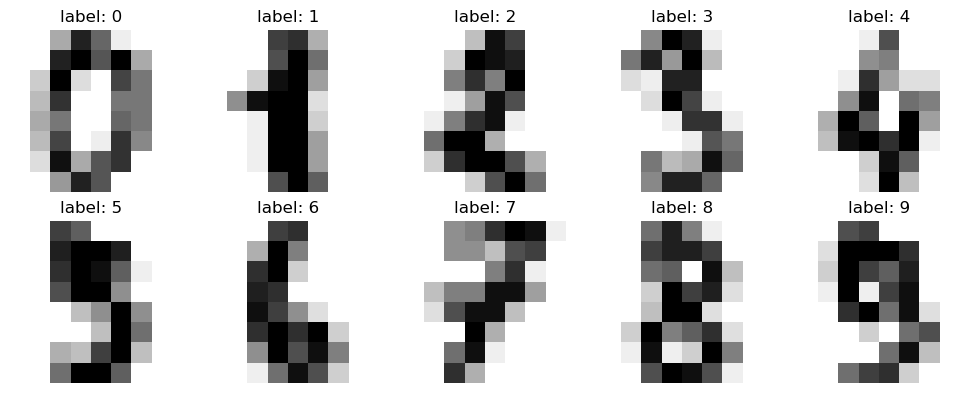

In [105]:
# Show example digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.flatten(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"label: {label}")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

In [106]:
# 50/50 train/test split (shuffle for interleaved class presentations — critical for STDP LTD)
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    digits.data, digits.target, test_size=0.5, shuffle=True, random_state=42
)
n_classes = len(np.unique(digits.target))
input_size = X_train.shape[1]  # 64 pixels
print(f"Train: {len(X_train)}, Test: {len(X_test)}, Classes: {n_classes}, Input size: {input_size}")

Train: 898, Test: 899, Classes: 10, Input size: 64


## Network Architecture

We use the tuned `digits_config.yaml` unchanged, together with **our own learning rule**, defined in
`user_customized_stdp.py` next to this notebook.

| Component | Count | Config | Purpose |
|-----------|-------|--------|---------|
| Input somas | 64 | `digits_input_config` | LIF neurons, one per pixel, `vthr = -59.5` (0.5 above rest) |
| Output somas | 10 | `digits_output_config` | LIF neurons, one per class, `vthr = -41` (19 above rest) |
| Input synapses | 64 | `digits_input_synapse_config` | External → input somas, weight 1.0, no learning |
| Target synapses | 10 | `digits_target_synapse_config` | External → output somas, weight 1.0, no learning |
| Learning synapses | 640 | `digits_learning_synapse_config` | Input → output, `user_customized_stdp`, weights bounded to [0, 1] |

With `C = 1e-9`, `R = 1e6` and `scaling_factor = 1e-6` at `dt = 1e-3`, the synaptic gain
`scaling_factor · dt / C` works out to exactly **1.0** — so one unit of synaptic current moves the
membrane by one unit, and the thresholds above read directly as "how much drive is needed to fire".

### Bringing your own learning rule

A synapse has two independent parts: its **breed** (the synaptic current dynamics — here the built-in
`single_exp_synapse`) and its **learning rule** (how the weight changes). Any breed can carry any
registered rule, so we keep the built-in dynamics and swap in our own plasticity.

Three steps:

1. **Write the kernel.** `user_customized_stdp.py` defines a `@jit.rawkernel(device="cuda")` function
   with the framework's fixed 16-argument signature. It implements a SuperNeuroMAT-style bounded rule:
   on a post-synaptic spike, potentiate by `pre_trace` if the pre-synaptic neuron fired recently,
   otherwise depress by `a_exp_post`; clip to `[wmin, wmax]`.
2. **Register it before `setup()`.** `model.register_learning_rule(...)` returns an auto-assigned
   integer id. The four built-in rules take 0–3, so ours gets **4**. `setup()` code-generates a
   dispatcher over all registered rules, which is why registration has to come first.
3. **Select it per synapse — without touching the config.** `learning_rule=` only chooses which YAML
   block supplies the hyperparameters, so we point at the tuned `exp_pair_wise_stdp_bounded` block and
   use its values as-is. What actually selects the kernel is `stdp_type`, which `create_synapse`
   overrides to our registered id. `digits_config.yaml` therefore needs no edit at all.

**Other design choices:**
- Amplitude encoding: each pixel's spike amplitude is proportional to its intensity (`pixel_value × 2.0/16`).
- **Target spikes** during training force the correct output neuron to fire (at T+1), providing the
  supervised signal that STDP needs to develop class-specific weight patterns.
- The tuned config sets `a_exp_post = 0.0`, which switches this rule's depression branch off entirely —
  weights only grow, held in check by the `wmax = 1` clamp rather than by LTD.
- Shuffled training data ensures interleaved class presentations, so consecutive samples come from
  different classes.

In [107]:
# Create model with custom config
CONFIG_DIR = Path(".").resolve()
model = NeuromorphicModel(
    user_config=CONFIG_DIR / "digits_config.yaml",
    enable_internal_states_tracking=False,
)

# Register our own learning rule. Must happen before setup(), which is what
# generates the dispatch code. The four built-in rules occupy ids 0-3, so the
# first custom rule gets id 4; synapses select it by setting stdp_type to that id.
STDP_RULE_ID = model.register_learning_rule(
    step_func=user_customized_stdp,
    step_func_path=CONFIG_DIR / "user_customized_stdp.py",
)
print(f"Registered 'user_customized_stdp' as learning rule id {STDP_RULE_ID}")

Registered 'user_customized_stdp' as learning rule id 4


In [108]:
def create_layer(model, size, config_name):
    """Create a layer of LIF somas."""
    ids = []
    for _ in range(size):
        soma_id = model.create_soma(
            breed="lif_soma",
            config_name=config_name,
        )
        ids.append(soma_id)
    return ids


def create_input_synapses(model, soma_ids, config_name):
    """Create one external-input synapse (pre=-1) per soma."""
    ids = []
    for soma_id in soma_ids:
        syn_id = model.create_synapse(
            breed="single_exp_synapse",
            pre_soma_id=-1,
            post_soma_id=soma_id,
            config_name=config_name,
        )
        ids.append(syn_id)
    return ids


def fully_connect(model, pre_ids, post_ids, config_name, stdp_rule_id):
    """Create plastic synapses between all pairs, driven by our custom rule.

    `learning_rule=` only selects which YAML block supplies the hyperparameters,
    so we point at the tuned `exp_pair_wise_stdp_bounded` block and take its
    values unchanged. What actually picks the kernel is `stdp_type`, which we
    override to our registered rule id -- leaving digits_config.yaml untouched.
    """
    syn_ids = []
    for pre_id in pre_ids:
        for post_id in post_ids:
            syn_id = model.create_synapse(
                breed="single_exp_synapse",
                pre_soma_id=pre_id,
                post_soma_id=post_id,
                config_name=config_name,
                learning_rule="exp_pair_wise_stdp_bounded",
                learning_rule_config="digits_learning",
                overrides={
                    "hyperparameters": {"weight": 0 * np.random.uniform(0.0, 1.0)},
                    "learning_hyperparameters": {"stdp_type": float(stdp_rule_id)},
                },
            )
            syn_ids.append(syn_id)
    return syn_ids

In [109]:
# Build the network
input_somas = create_layer(model, input_size, config_name="digits_input_config")
output_somas = create_layer(model, n_classes, config_name="digits_output_config")

input_synapses = create_input_synapses(model, input_somas, config_name="digits_input_synapse_config")
target_synapses = create_input_synapses(model, output_somas, config_name="digits_target_synapse_config")
learning_synapses = fully_connect(
    model, input_somas, output_somas,
    config_name="digits_learning_synapse_config",
    stdp_rule_id=STDP_RULE_ID,
)

print(f"Input somas: {len(input_somas)}")
print(f"Output somas: {len(output_somas)}")
print(f"Input synapses: {len(input_synapses)}")
print(f"Target synapses: {len(target_synapses)}")
print(f"Learning synapses: {len(learning_synapses)}")
print(f"Total agents: {len(input_somas) + len(output_somas) + len(input_synapses) + len(target_synapses) + len(learning_synapses)}")

# Confirm the override landed: this must be STDP_RULE_ID, not the -1.0 placeholder.
print(f"stdp_type on a learning synapse: "
      f"{model.get_learning_hyperparameters(learning_synapses[0])['stdp_type']}")

Input somas: 64
Output somas: 10
Input synapses: 64
Target synapses: 10
Learning synapses: 640
Total agents: 788
stdp_type on a learning synapse: 4.0


## Training Encoding

Each training sample is presented over **10 ticks** (spacing must exceed refractory period of 5 ticks + fire latency of 2 ticks = 7 ticks, so input somas clear refractory before the next sample arrives):
- **Tick T+0**: Amplitude-encoded input spikes (`pixel_value × SPIKE_SCALE`), matching tutorial 01's approach
- **Tick T+1**: Target spike forces the correct output neuron to fire (matching tutorial 01's T+1 offset)
- **Ticks T+2..T+9**: STDP processes, voltages decay, refractory clears

We run **2 training epochs**. With bounded STDP where LTD slightly exceeds LTP, class-specific weights
reach ~0.64 after 1 epoch and approach 1.0 after 2. More epochs risk saturating even partially-specific
pixels, reducing discrimination. Between epochs, `reset(retain_parameters=True)` preserves learned
weights while clearing internal state, and spikes are re-injected for the next pass.

In [110]:
# Encoding parameters
SPIKE_SCALE = 2.0 / 16.0  # amplitude scale matching tutorial 01
TICKS_PER_SAMPLE = 6      # spacing between samples; 
TARGET_OFFSET = 1         # target spike at T+1, matching tutorial 01
N_EPOCHS = 1               # number of training epochs

def encode_training_spikes(model, X_train, y_train, input_synapses, target_synapses):
    """Encode training data as amplitude-scaled spike lists and inject into the model."""
    input_spike_lists = {syn_id: [] for syn_id in input_synapses}
    target_spike_lists = {syn_id: [] for syn_id in target_synapses}

    for sample_idx, (image, label) in enumerate(zip(X_train, y_train)):
        t_base = sample_idx * TICKS_PER_SAMPLE
        for pixel_idx, pixel_val in enumerate(image):
            amplitude = pixel_val * SPIKE_SCALE
            if amplitude > 0:
                input_spike_lists[input_synapses[pixel_idx]].append([t_base, amplitude])
        # Target spike forces correct output neuron to fire at T+1
        target_spike_lists[target_synapses[label]].append([t_base + TARGET_OFFSET, 20.0])
        print(f"Sample {sample_idx}: label={label}, target_synapse={target_synapses[label]}, spike_time={t_base + TARGET_OFFSET}, amplitude=1.0")
    # print(input_spike_lists[76])
    print(target_synapses)
    print(target_spike_lists[target_synapses[4]])
    for syn_id, spikes in input_spike_lists.items():
        if spikes:
            model.add_spike_list(syn_id, spikes)
    for syn_id, spikes in target_spike_lists.items():
        if spikes:
            model.add_spike_list(syn_id, spikes)

total_training_ticks = len(X_train) * TICKS_PER_SAMPLE
print(f"Training samples: {len(X_train)}")
print(f"Total training ticks per epoch: {total_training_ticks}")
print(f"Training epochs: {N_EPOCHS}")

Training samples: 898
Total training ticks per epoch: 5388
Training epochs: 1


In [111]:
# Setup and run multi-epoch training (no normalization needed — bounded STDP constrains weights)
model.setup()
# model.set_recorded_somas([])
# X_train_debug = X_train[:50]
# y_train_debug = y_train[:50]
# X_train=X_train_debug
# Y_train=y_train_debug
encode_training_spikes(model, X_train, y_train, input_synapses, target_synapses)
# encode_training_spikes(model, X_train_debug, y_train_debug, input_synapses, target_synapses)
for epoch in range(N_EPOCHS):
    if epoch > 0:
        model.reset(retain_parameters=True)
        encode_training_spikes(model, X_train, y_train, input_synapses, target_synapses)
    model.simulate(ticks=total_training_ticks)
    print(f"Epoch {epoch + 1}/{N_EPOCHS} complete")

# spikes = model.get_all_spike_times() 
# print(f"Total spikes recorded: {len(spikes)}")
# print(spikes)
# for i, sid in enumerate(output_somas):
#       print(f"output {i}: fired at {model.get_spike_times(sid)}")

# for i, sid in enumerate(input_somas):
#       print(f"input {i}: fired at {model.get_spike_times(sid)}")

Sample 0: label=4, target_synapse=142, spike_time=1, amplitude=1.0
Sample 1: label=9, target_synapse=147, spike_time=7, amplitude=1.0
Sample 2: label=5, target_synapse=143, spike_time=13, amplitude=1.0
Sample 3: label=9, target_synapse=147, spike_time=19, amplitude=1.0
Sample 4: label=7, target_synapse=145, spike_time=25, amplitude=1.0
Sample 5: label=6, target_synapse=144, spike_time=31, amplitude=1.0
Sample 6: label=5, target_synapse=143, spike_time=37, amplitude=1.0
Sample 7: label=6, target_synapse=144, spike_time=43, amplitude=1.0
Sample 8: label=5, target_synapse=143, spike_time=49, amplitude=1.0
Sample 9: label=6, target_synapse=144, spike_time=55, amplitude=1.0
Sample 10: label=2, target_synapse=140, spike_time=61, amplitude=1.0
Sample 11: label=6, target_synapse=144, spike_time=67, amplitude=1.0
Sample 12: label=8, target_synapse=146, spike_time=73, amplitude=1.0
Sample 13: label=0, target_synapse=138, spike_time=79, amplitude=1.0
Sample 14: label=2, target_synapse=140, spike_

## Extract and Visualize Learned Weights

In [112]:
# Extract the 64x10 weight matrix from learning synapses
# learning_synapses is ordered: [input_0->output_0, input_0->output_1, ..., input_63->output_9]
weight_matrix = np.zeros((input_size, n_classes))
for i, hp in enumerate(model.get_hyperparameters(learning_synapses)):
    pre_idx = i // n_classes
    post_idx = i % n_classes
    weight_matrix[pre_idx, post_idx] = hp["weight"]

print(f"Weight matrix shape: {weight_matrix.shape}")
print(f"Weight range: [{weight_matrix.min():.4f}, {weight_matrix.max():.4f}]")

Weight matrix shape: (64, 10)
Weight range: [0.0000, 0.6400]


/tmp/ipykernel_146664/3024826887.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


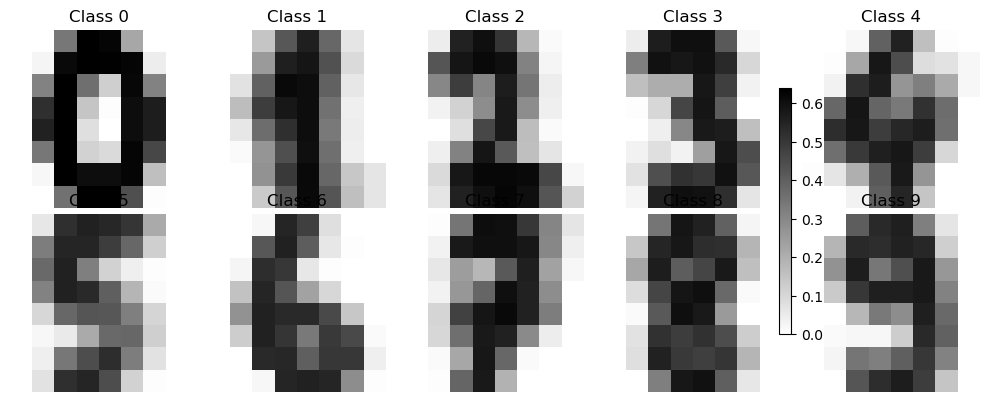

In [113]:
# Visualize learned weight patterns per class as 8x8 images
# Mean-subtracted: highlights what's *distinctive* about each class
# images = weight_matrix.T.reshape(n_classes, 8, 8)
# mean_image = images.mean(axis=0)
# fig, axes = plt.subplots(2, 5, figsize=(10, 4))
# for ax, image, cls in zip(axes.flatten(), images, range(n_classes)):
#     ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
#     ax.set_title(f"class: {cls}")
#     ax.set_axis_off()
# plt.tight_layout()
# plt.show()
images = weight_matrix.T.reshape(n_classes, 8, 8)

vmin = weight_matrix.min()   # wmin
vmax = weight_matrix.max()    # wmax

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, cls in zip(axes.flat, images, range(n_classes)):
    im = ax.imshow(
        image,
        cmap="gray_r",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"Class {cls}")
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()
plt.show()

## Per-Sample Inference with Spike-Count Readout

After training, we disable STDP and run inference **one sample at a time** with
`reset(retain_parameters=True)` between samples. This fully clears internal state
(synaptic current, membrane voltage) so each sample is classified in isolation.
`reset()` also rewinds the tick counter to 0, so recorded spike times are
sample-relative.

### Changing the operating point for inference

A network usually cannot infer under the same parameters it trained under — tutorial 01
switches to perfect integrators, a much higher output threshold and rescaled weights
before testing, and this network needs the same kind of move (its output threshold is
sized to sit *above* the largest learned drive so that only the supervisory target spike
fires an output during training; with no target spike at inference, nothing fires).

SuperNeuroABM lets you do that **on the trained model, in place** — there is no need to
save the weights and rebuild. Use `set_hyperparameters`, which takes parameters *by name*:

```python
model.set_hyperparameters(input_somas, {"R": 1e12, "tref": 0.0})
model.set_hyperparameters(output_somas[0], {"vthr": -25.0})   # one agent or many
model.get_hyperparameters(output_somas[0])["vthr"]            # read it back
```

Each parameter is read out of a per-agent tensor inside the CUDA kernel on every tick, so
writing it genuinely changes behaviour, and `reset(retain_parameters=True)` deliberately
leaves those values alone — so overrides ride along with the learned weights through every
per-sample reset. (`setup()` cannot be called twice, so "rebuild with a new config" would
mean constructing a second `NeuromorphicModel`; only worth it for things fixed at build
time, such as synaptic delays.)

**One ordering rule.** Writes land on the CPU-side copy, but after `simulate()` the GPU
holds values the CPU has never seen — the STDP-learned weights. Writing at that moment
would make the next `simulate()` re-upload the stale CPU array and lose them, so
`reset(retain_parameters=True)` (currently the only GPU→CPU sync) has to come first:

> `simulate()` → `reset(retain_parameters=True)` → `eval()` → parameter writes → `simulate()`

`set_hyperparameters` **raises rather than corrupting the model** if you get this wrong, so
this is a rule you get told about rather than one you have to remember.
`docs/CPU_GPU_DATA_FLOW.md` explains the whole picture.

The next cell defines `INFER_INPUT_SOMA_PARAMS`, `INFER_OUTPUT_SOMA_PARAMS` and
`INFER_WEIGHT_FN` as the single place to set those values. They currently hold tutorial 01's
inference parameters, transplanted directly with no retuning.

The learned weights are re-plotted twice below — once after the operating point is switched,
and again after the full test set has run — so you can confirm by eye that neither the
parameter writes nor the 899 per-sample `reset()` calls disturbed what STDP learned.

### Readout

We decode the output layer the same way tutorial 01 does — a **hierarchical
winner-take-all on output spikes**:

1. the output neuron(s) with the **most spikes**;
2. of those, the one(s) that spiked **soonest** (smallest sum of spike times).

Ties are kept, so the prediction is a *list* of classes and is scored multi-label.
`model.get_spike_times(soma_id)` returns the ticks at which a soma fired; `simulate()`
clears the spike log on entry, so each call sees only that sample's spikes.

For inference, we use a lower amplitude scale (`1/16 × 0.1`) with repeated spikes
over 20 ticks, matching tutorial 01's inference encoding approach.

In [ ]:
# ---------------------------------------------------------------------------
# INFERENCE OPERATING POINT -- owned by whoever owns digits_config.yaml.
#
# These are tutorial 01's inference parameters transplanted directly, with no
# retuning, mapped onto this LIF:
#
#   01: neuron_leaks = 0 (perfect integrators)  ->  leak/tick = dt/(R*C), so R = 1e12
#       (raise R, not C: C also sets the input gain dt*scaling_factor/C = 1.0)
#   01: input threshold  0.5                    ->  vthr - vrest = 0.5   -> vthr = -59.5
#   01: output threshold 35                     ->  vthr - vrest = 35    -> vthr = -25.0
#   01: refractory_period = 0                   ->  tref = 0             (config has 2 ticks)
#   01: weights[stdp] += 5; weights *= 0.5      ->  INFER_WEIGHT_FN
#
# vthr on the input layer already equals -59.5 in the config; it is written out
# here anyway so the mapping to 01 is explicit rather than implicit.
#
# Tuning these is a config question, not a readout one -- see the accuracy the
# notebook reports below before changing them.
#
# lif_soma knobs: C, R, vthr, tref, vrest, vreset, tref_allows_integration,
#                 I_in, scaling_factor
#   leak fraction per tick = dt / (R * C)
#   drive per tick         = I_synapse * dt * scaling_factor / C
#   effective threshold    = vthr - vrest
#   refractory period      = tref / dt ticks
# ---------------------------------------------------------------------------
# INFER_INPUT_SOMA_PARAMS = { "vthr": -59.5 }
INFER_OUTPUT_SOMA_PARAMS = { "vthr": -47.9, "R": 1e12 }
# INFER_WEIGHT_FN = lambda w: (w + 5.0) * 0.5

In [115]:
# Prepare for inference: keep trained weights, disable learning, switch operating point.
#
# reset() FIRST, and this is not optional. It is currently the only point where GPU
# state is synced back to the CPU, and set_hyperparameters() will refuse to run
# before it -- see docs/CPU_GPU_DATA_FLOW.md for why.
model.reset(retain_parameters=True)

# Freeze plasticity. Like PyTorch's eval(), this only flips the mode -- it does not
# clear membrane voltage or synaptic current, which is what reset() above is for.
# Weights are untouched, so the learned pattern is what drives the outputs.
model.eval()

# Switch to the inference operating point. Parameters are named, so nothing here
# depends on their position in digits_config.yaml. An empty dict is a no-op.
# reset(retain_parameters=True) never touches hyperparameters, so these overrides
# ride along with the learned weights through infer_single()'s per-sample reset.
# model.set_hyperparameters(input_somas, INFER_INPUT_SOMA_PARAMS)
model.set_hyperparameters(output_somas, INFER_OUTPUT_SOMA_PARAMS)

# if INFER_WEIGHT_FN is not None:
#     for syn, hp in zip(learning_synapses, model.get_hyperparameters(learning_synapses)):
#         model.set_hyperparameters(syn, {"weight": INFER_WEIGHT_FN(hp["weight"])})

# Last, so the spike mask is rebuilt after the writes above.
# model.set_recorded_somas(output_somas)

input soma   leak/tick=1          thr-vrest=0.5      tref=2 ticks
output soma  leak/tick=1          thr-vrest=12.1     tref=2 ticks


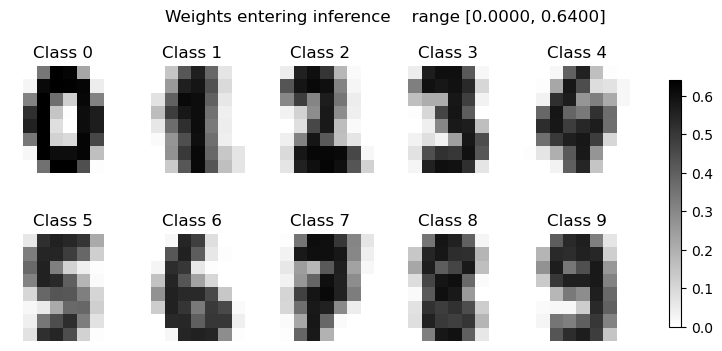

In [116]:
# Read back what actually landed in the tensors, in effective units rather than raw
# fields, then re-plot the learned weights. Compare this plot against the post-training
# one above: the *pattern* must be identical, confirming that switching the operating
# point did not disturb what STDP learned.
#
# Expect small rounding: GPU tensors are float32, so any value that has round-tripped
# through the device comes back quantized (1e-9 reads back as 9.9999997e-10). Cosmetic.
DT = model.get_global_property_value("dt")


def report_soma(label, soma_id):
    p = model.get_hyperparameters(soma_id)
    print(f"{label:<12s} leak/tick={DT / (p['R'] * p['C']):<10.3g} "
          f"thr-vrest={p['vthr'] - p['vrest']:<8.3g} tref={p['tref'] / DT:.0f} ticks")


def plot_weight_patterns(title):
    """Re-read every plastic weight from the model and plot it as 8x8 per-class images.

    Each call autoscales to its own range, so the *pattern* stays directly comparable
    across calls even after an affine rescale like INFER_WEIGHT_FN; the absolute range
    is printed in the title so the rescale is still visible.
    """
    w = np.zeros((input_size, n_classes))
    for i, hp in enumerate(model.get_hyperparameters(learning_synapses)):
        w[i // n_classes, i % n_classes] = hp["weight"]

    images = w.T.reshape(n_classes, 8, 8)
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for ax, image, cls in zip(axes.flat, images, range(n_classes)):
        im = ax.imshow(image, cmap="gray_r", interpolation="nearest",
                       vmin=w.min(), vmax=w.max())
        ax.set_title(f"Class {cls}")
        ax.axis("off")
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    fig.suptitle(f"{title}    range [{w.min():.4f}, {w.max():.4f}]")
    plt.show()
    return w


report_soma("input soma", input_somas[0])
report_soma("output soma", output_somas[0])

# Snapshot to compare against after the inference loop has run.
weights_before_inference = plot_weight_patterns("Weights entering inference")

In [117]:
INFERENCE_TICKS = 25
INFER_INPUT_TICKS = 20
INFER_SPIKE_SCALE = (2.0 / 16.0)  # matching tutorial 01: (1/input_max) * input_scaling
# These three are *encoding* parameters, not model config -- the neuron and synapse side
# of the inference operating point lives in INFER_INPUT_SOMA_PARAMS /
# INFER_OUTPUT_SOMA_PARAMS / INFER_WEIGHT_FN a few cells up. The two have to agree: at
# the 0.1x scale above the peak amplitude is 0.1 against an input threshold of 0.5, which
# only ever reaches threshold if the input somas are also switched to integrate
# (leak = 0), which is exactly what tutorial 01 does before testing.

def infer_single(model, image, input_synapses, output_somas):
    """Classify one image by output spike counts.

    Returns the list of winning class indices (a list, not a scalar: ties are kept,
    matching tutorial 01's multi-label decoder).
    """
    for pixel_idx, pixel_val in enumerate(image):
        amplitude = pixel_val * INFER_SPIKE_SCALE
        if amplitude > 0:
            spike_list = [[tick, amplitude] for tick in range(INFER_INPUT_TICKS)]


    # for pixel_idx, pixel_val in enumerate(image):
    #     amplitude = pixel_val * SPIKE_SCALE
    #     spike_list = []
    #     if amplitude > 0:

    #         spike_list.append([0, amplitude])

            model.add_spike_list(synapse_id=input_synapses[pixel_idx], spike_list=spike_list)
        
    model.simulate(ticks=INFERENCE_TICKS)

    # # Hierarchical winner-take-all, matching tutorial 01:
    # #   1. the output soma(s) with the most spikes
    # #   2. of those, the one(s) that spiked soonest (min sum of spike times)
    # # The index of a soma within output_somas is its class label.
    # spike_times = [model.get_spike_times(soma_id) for soma_id in output_somas]
    # counts = [len(ts) for ts in spike_times]

    # most_spikes = max(counts)
    # matching = [i for i, c in enumerate(counts) if c == most_spikes]
    # fastest = min(sum(spike_times[i]) for i in matching)
    # # Note: if nothing fired, most_spikes == 0 and every sum is 0, so all 10 classes
    # # are returned — the same degenerate behaviour as tutorial 01, kept for comparability.
    # answers = [i for i in matching if sum(spike_times[i]) == fastest]

    # # Clears voltage / synaptic current / spike log and rewinds the tick counter, so the
    # # next sample starts clean. retain_parameters=True keeps both the learned weights and
    # # the inference overrides applied above; retain_parameters=False would discard both.
    # model.reset(retain_parameters=True)
    # return answers

In [118]:
infer_single(model, X_test[0], input_synapses, output_somas)

spikes = model.get_all_spike_times() 
# print(f"Total spikes recorded: {len(spikes)}")
# print(spikes)
for i, sid in enumerate(output_somas):
      print(f"output {i}: fired at {model.get_spike_times(sid)}")

for i, sid in enumerate(input_somas):
      print(f"input {i}: fired at {model.get_spike_times(sid)}")

print(y_test[0])

output 0: fired at [3, 6, 9, 12, 17, 22]
output 1: fired at []
output 2: fired at []
output 3: fired at []
output 4: fired at []
output 5: fired at []
output 6: fired at [3, 6, 9, 12, 17, 22]
output 7: fired at []
output 8: fired at [3, 6, 9, 12, 17, 22]
output 9: fired at []
input 0: fired at []
input 1: fired at []
input 2: fired at []
input 3: fired at [1, 4, 7, 10, 12, 15, 17, 20]
input 4: fired at [1, 4, 7, 10, 12, 15, 17, 20]
input 5: fired at []
input 6: fired at []
input 7: fired at []
input 8: fired at []
input 9: fired at []
input 10: fired at [1, 4, 7, 10, 12, 15, 17, 20]
input 11: fired at [1, 4, 7, 10, 12, 15, 17, 20]
input 12: fired at [1, 4, 7, 10, 12, 15, 17, 20]
input 13: fired at []
input 14: fired at []
input 15: fired at []
input 16: fired at []
input 17: fired at []
input 18: fired at [1, 4, 7, 10, 12, 15, 17, 20]
input 19: fired at [1, 4, 7, 10, 12, 15, 17, 20]
input 20: fired at []
input 21: fired at []
input 22: fired at []
input 23: fired at []
input 24: fired 

## Evaluation

In [119]:
def binarize(a, classes):
    """One-hot / multi-hot a list of labels over `classes` (matching tutorial 01)."""
    return [label in a for label in classes]


# Multi-label scoring, matching tutorial 01: each sample contributes one slot per class.
tp = tn = fp = fn = 0
strict = 0
predictions = []
binary_predictions = []
classes = np.unique(y_test)

for image, real_answer in tqdm(zip(X_test, y_test), total=len(y_test)):
    answers = infer_single(model, image, input_synapses, output_somas)

    for label in classes:
        tp += label == real_answer and label in answers
        fn += label == real_answer and label not in answers
        tn += label != real_answer and label not in answers
        fp += label != real_answer and label in answers

    strict += answers == [real_answer]  # sole winner, and it is correct

    binary_predictions.append((binarize([real_answer], classes), binarize(answers, classes)))
    for answer in answers:
        predictions.append((real_answer, answer))

# tp + fn == len(y_test), so Recall is the "true class was among the winners" hit-rate —
# this is the number directly comparable to tutorial 01. The Accuracy below is element-wise
# over len(y_test) x n_classes label slots and is inflated by the many true negatives.
print()
print(f"Precision: {tp / (tp + fp):>.6f} | Recall: {tp / (tp + fn):>.6f} | "
      f"Accuracy: {(tp + tn) / (tp + tn + fp + fn):>.6f} | F1: {tp / (tp + 0.5 * (fp + fn)):>.6f}")
print(f"Strict top-1 accuracy (single correct winner, no ties): {strict / len(y_test):.2%}")

# Weights after the full inference pass. eval() froze plasticity and every sample ended in
# reset(retain_parameters=True), so 899 rounds of inject/simulate/reset must not erode what
# was learned.
#
# The snapshot above was taken from values we had just written as float64. The first
# simulate() uploads them to the float32 GPU tensors and the first reset() downloads that
# back, so exactly one quantization step is expected and is NOT learning. The precise test
# is therefore against the float32 image of the snapshot, which must match exactly.
print()
weights_after_inference = plot_weight_patterns("Weights after inference")

quantized = weights_before_inference.astype(np.float32).astype(np.float64)
drift = np.abs(weights_after_inference - weights_before_inference).max()
leak = np.abs(weights_after_inference - quantized).max()
print(f"Drift vs snapshot:          {drift:.3e}  "
      f"(float32 ulp here is {np.spacing(np.float32(weights_before_inference.max())):.3e} -- expected)")
print(f"Drift vs float32(snapshot): {leak:.3e}  "
      f"({'unchanged, plasticity stayed frozen' if leak == 0 else 'CHANGED -- plasticity leaked into inference'})")

  0%|          | 0/899 [00:00<?, ?it/s]


TypeError: argument of type 'NoneType' is not iterable

In [ ]:
# Confusion matrix (one row per (true label, winning class) pair — ties contribute several rows)
disp = sklearn.metrics.ConfusionMatrixDisplay.from_predictions(*zip(*predictions))
disp.figure_.suptitle("Confusion Matrix")
print(f"Confusion matrix:\n{disp.confusion_matrix}")
plt.show()

In [ ]:
# Per-class classification report over the binarized multi-label predictions
b_test, b_pred = np.array(list(zip(*binary_predictions)))
print(sklearn.metrics.classification_report(b_test, b_pred, zero_division=0))

tp, tn, fp, fn